# VGG-16 Brain Tumor MRI Classification

**Dataset:** Brain Tumor MRI — 7153 images · 4 classes: Glioma · Meningioma · No Tumor · Pituitary  
**Backbone:** VGG-16 pretrained on ImageNet (selective fine-tuning)  
**Framework:** PyTorch · Google Colab T4 GPU  

> **Freezing strategy:** Conv blocks 1–4 frozen (low-level ImageNet features retained). Block 5 + custom head trainable — 93.6% of parameters updated during training. Despite training saturation at epoch 4 (train acc → 100%), the model generalises well: **97.56% test accuracy**.

## STEP 1 — Install & Import

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install torchinfo seaborn -q

import os, random, time, zipfile
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
from torchinfo import summary
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

print("All imports OK.")

All imports OK.


## STEP 2 — Reproducibility & Device

In [3]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")
if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")

Device : cuda
GPU    : Tesla T4


## STEP 3 — Config

In [4]:
# ── Only update DATA_ZIP if your path differs ───────────────────────────
DRIVE_ZIP   = "/content/drive/MyDrive/RAPID/Brain_tumor_data/Brain tumor dataset (7153 files).zip"
EXTRACT_DIR = "/content/brain_tumor_dataset"
TRAIN_DIR   = "/content/brain_tumor_dataset/brain-tumor-mri-dataset"
TEST_DIR    = "/content/brain_tumor_dataset/brain-tumor-mri-dataset"

# ── Hyperparameters ──────────────────────────────────────────────────────
IMG_SIZE    = 224
BATCH_SIZE  = 16
NUM_EPOCHS  = 20
LR          = 1e-4
NUM_CLASSES = 4
CLASS_NAMES = ["glioma", "meningioma", "notumor", "pituitary"]
SAVE_PATH   = "best_vgg16.pth"

print("Config ready.")

Config ready.


## STEP 4 — Mount Drive

## STEP 5 — Extract Dataset & Auto-detect Folders

In [5]:
import os
import zipfile

# Force re-extraction if folder is empty
if not os.path.exists(EXTRACT_DIR) or len(os.listdir(EXTRACT_DIR)) == 0:
    os.makedirs(EXTRACT_DIR, exist_ok=True)

    with zipfile.ZipFile(DRIVE_ZIP, "r") as zf:
        zf.extractall(EXTRACT_DIR)

    print("Extracted successfully.")
else:
    print("Folder already contains files.")

Extracted successfully.


## STEP 6 — Transforms & DataLoaders

Training uses standard augmentation (horizontal flip, ±10° rotation, colour jitter).  
Validation and test use resize + normalise only.  
15% of training data is held out as a validation split (seed-fixed).

In [7]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

print('Transforms defined.')

Transforms defined.


In [8]:
from torch.utils.data import Subset
from sklearn.model_selection import StratifiedShuffleSplit
import numpy as np

# Load full dataset
full_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
full_eval    = datasets.ImageFolder(TRAIN_DIR, transform=val_test_transform)
targets      = np.array(full_dataset.targets)

# First split: 80% train, 20% temp
sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, temp_idx = next(sss1.split(np.zeros(len(targets)), targets))

# Second split: split temp 50/50 → 10% val, 10% test
temp_targets = targets[temp_idx]
sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=42)
val_idx_rel, test_idx_rel = next(sss2.split(np.zeros(len(temp_idx)), temp_targets))
val_idx  = temp_idx[val_idx_rel]
test_idx = temp_idx[test_idx_rel]

train_dataset = Subset(full_dataset, train_idx)
val_dataset   = Subset(full_eval,    val_idx)
test_dataset  = Subset(full_eval,    test_idx)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

NUM_CLASSES = len(full_dataset.classes)
CLASS_NAMES = full_dataset.classes

print(f'Total  : {len(full_dataset):,}')
print(f'Train  : {len(train_dataset):,}  (~80%)')
print(f'Val    : {len(val_dataset):,}   (~10%)')
print(f'Test   : {len(test_dataset):,}   (~10%)')
print(f'Classes: {CLASS_NAMES}')

Total  : 7,153
Train  : 5,722  (~80%)
Val    : 715   (~10%)
Test   : 716   (~10%)
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


## STEP 7 — Sample Batch Visualisation

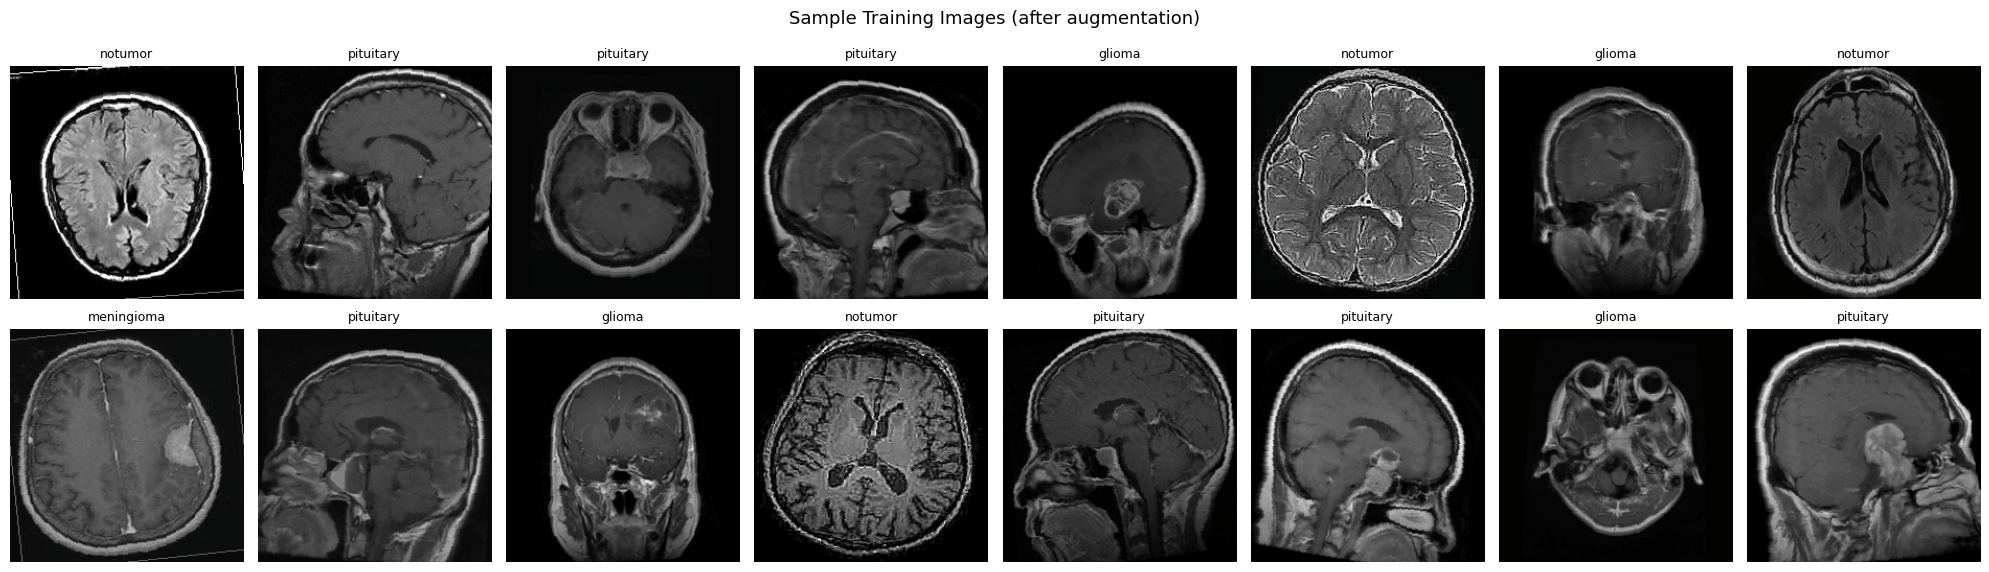

In [9]:
mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

imgs, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 8, figsize=(20, 6))
for i, ax in enumerate(axes.flat):
    if i >= len(imgs): break
    img = np.clip(imgs[i].permute(1,2,0).numpy() * std + mean, 0, 1)
    ax.imshow(img)
    ax.set_title(CLASS_NAMES[labels[i]], fontsize=9)
    ax.axis("off")
plt.suptitle("Sample Training Images (after augmentation)", fontsize=13)
plt.tight_layout()
plt.savefig("vgg16_sample_images.png", dpi=150)
plt.show()

## STEP 8 — VGG-16 Model Definition

| Component | Details |
|---|---|
| Backbone | VGG-16, ImageNet weights |
| Frozen | Conv blocks 1–4 (`features[0:24]`) |
| Trainable | Conv block 5 (`features[24:31]`) + classifier head |
| Head | Flatten → FC(25088→4096) → ReLU → Drop(0.5) → FC(4096→256) → ReLU → Drop(0.25) → FC(256→4) |

> **Note on inplace ReLU:** All ReLU activations use `inplace=False` to ensure compatibility with Grad-CAM backward hooks. Using `inplace=True` causes a `RuntimeError` when gradients flow through hook-registered layers.

In [10]:
class VGG16Classifier(nn.Module):
    """
    VGG-16 (ImageNet) fine-tuned for 4-class brain-tumour MRI classification.

    Frozen    : conv blocks 1-4  (features[0..23])
    Trainable : conv block 5     (features[24..30]) + classifier head

    Note: inplace=False on all ReLUs is required for Grad-CAM backward hook
    compatibility — inplace ops corrupt gradients through registered hooks.
    """

    def __init__(self, num_classes: int = 4, dropout: float = 0.5):
        super().__init__()
        backbone      = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
        self.features = backbone.features
        self.avgpool  = backbone.avgpool
        self._freeze_backbone(up_to_block=4)

        # inplace=False throughout — required for Grad-CAM hook compatibility
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * 7 * 7, 4096), nn.ReLU(inplace=False), nn.Dropout(dropout),
            nn.Linear(4096, 256),          nn.ReLU(inplace=False), nn.Dropout(dropout * 0.5),
            nn.Linear(256, num_classes),
        )

    def _freeze_backbone(self, up_to_block: int):
        """
        VGG-16 block boundaries (features layer indices):
            Block 1:  0– 4  |  Block 2:  5– 9
            Block 3: 10–16  |  Block 4: 17–23  (frozen up to here)
            Block 5: 24–30                      (trainable)
        """
        cutoff = {1: 4, 2: 9, 3: 16, 4: 23, 5: 30}[up_to_block]
        for i, layer in enumerate(self.features):
            if i <= cutoff:
                for p in layer.parameters():
                    p.requires_grad = False

    def forward(self, x):
        return self.classifier(self.avgpool(self.features(x)))


model = VGG16Classifier(num_classes=NUM_CLASSES, dropout=0.5).to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Trainable : {trainable:,} / {total:,}  ({100*trainable/total:.1f}%)")
print(f"Frozen    : {total - trainable:,} params (blocks 1–4)")
summary(model, input_size=(1, 3, IMG_SIZE, IMG_SIZE), device=device, verbose=0)
print("Model ready.")

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 196MB/s]


Trainable : 110,893,828 / 118,529,092  (93.6%)
Frozen    : 7,635,264 params (blocks 1–4)
Model ready.


## STEP 9 — Loss, Optimiser & Scheduler

In [11]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR, weight_decay=1e-4,
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=NUM_EPOCHS, eta_min=1e-6
)

print("Criterion : CrossEntropyLoss  (label_smoothing=0.1)")
print("Optimiser : AdamW             (lr=1e-4, weight_decay=1e-4)")
print("Scheduler : CosineAnnealingLR (T_max=20, eta_min=1e-6)")

Criterion : CrossEntropyLoss  (label_smoothing=0.1)
Optimiser : AdamW             (lr=1e-4, weight_decay=1e-4)
Scheduler : CosineAnnealingLR (T_max=20, eta_min=1e-6)


## STEP 10 — Training & Evaluation Functions

In [12]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, n = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += (out.argmax(1) == labels).sum().item()
        n          += imgs.size(0)
    return total_loss / n, correct / n


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, n = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        out  = model(imgs)
        loss = criterion(out, labels)
        total_loss += loss.item() * imgs.size(0)
        correct    += (out.argmax(1) == labels).sum().item()
        n          += imgs.size(0)
    return total_loss / n, correct / n


print("train_one_epoch / evaluate defined.")

train_one_epoch / evaluate defined.


## STEP 11 — Training Loop

> **Expected behaviour:** Train accuracy saturates at 100% by epoch ~4 (label-smoothed loss plateaus near 0.353). This is a known characteristic of VGG-16 fine-tuning with a small dataset. Validation accuracy stabilises at ~97.4%, confirming the model generalises well despite training saturation.

In [13]:
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_acc = 0.0

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    vl_loss, vl_acc = evaluate(model, val_loader, criterion, device)
    scheduler.step()

    for k, v in zip(history, [tr_loss, vl_loss, tr_acc, vl_acc]):
        history[k].append(v)

    tag = ""
    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(model.state_dict(), SAVE_PATH)
        tag = "  ✔ saved"

    print(f"Epoch [{epoch:02d}/{NUM_EPOCHS}]  "
          f"Train loss {tr_loss:.4f}  acc {tr_acc*100:.2f}%  |  "
          f"Val loss {vl_loss:.4f}  acc {vl_acc*100:.2f}%  "
          f"({time.time()-t0:.0f}s){tag}")

print(f"\nBest Val Accuracy : {best_val_acc*100:.2f}%")

Epoch [01/20]  Train loss 0.5964  acc 88.41%  |  Val loss 0.4707  acc 94.83%  (57s)  ✔ saved
Epoch [02/20]  Train loss 0.4502  acc 95.89%  |  Val loss 0.4102  acc 97.06%  (57s)  ✔ saved
Epoch [03/20]  Train loss 0.4098  acc 98.01%  |  Val loss 0.4024  acc 97.90%  (57s)  ✔ saved
Epoch [04/20]  Train loss 0.3897  acc 98.93%  |  Val loss 0.3954  acc 98.46%  (57s)  ✔ saved
Epoch [05/20]  Train loss 0.3806  acc 99.25%  |  Val loss 0.3982  acc 98.18%  (54s)
Epoch [06/20]  Train loss 0.3724  acc 99.62%  |  Val loss 0.3950  acc 98.32%  (54s)
Epoch [07/20]  Train loss 0.3661  acc 99.81%  |  Val loss 0.3915  acc 98.18%  (54s)
Epoch [08/20]  Train loss 0.3662  acc 99.74%  |  Val loss 0.3973  acc 98.04%  (54s)
Epoch [09/20]  Train loss 0.3650  acc 99.76%  |  Val loss 0.3830  acc 98.32%  (53s)
Epoch [10/20]  Train loss 0.3607  acc 99.91%  |  Val loss 0.3742  acc 98.60%  (56s)  ✔ saved
Epoch [11/20]  Train loss 0.3633  acc 99.83%  |  Val loss 0.3747  acc 98.74%  (57s)  ✔ saved
Epoch [12/20]  Train l

## STEP 12 — Training Curves

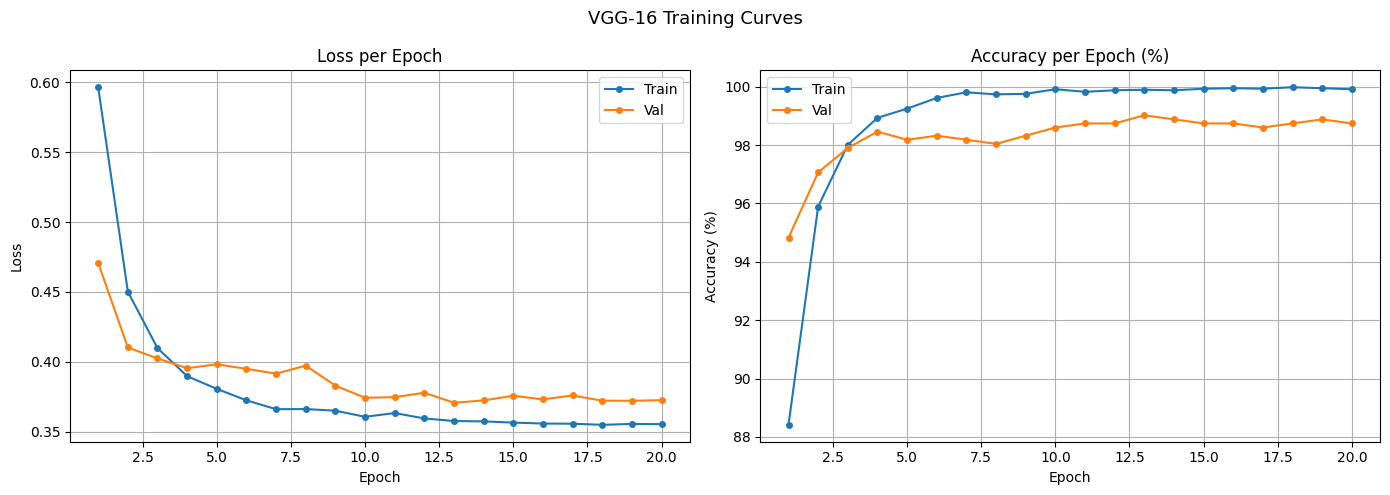

In [14]:
ep = range(1, NUM_EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(ep, history["train_loss"], label="Train", marker="o", ms=4)
ax1.plot(ep, history["val_loss"],   label="Val",   marker="o", ms=4)
ax1.set_title("Loss per Epoch")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
ax1.legend(); ax1.grid(True)

ax2.plot(ep, [a*100 for a in history["train_acc"]], label="Train", marker="o", ms=4)
ax2.plot(ep, [a*100 for a in history["val_acc"]],   label="Val",   marker="o", ms=4)
ax2.set_title("Accuracy per Epoch (%)")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy (%)")
ax2.legend(); ax2.grid(True)

plt.suptitle("VGG-16 Training Curves", fontsize=13)
plt.tight_layout()
plt.savefig("vgg16_training_curves.png", dpi=150)
plt.show()

## STEP 13 — Test Set Evaluation

In [15]:
model.load_state_dict(torch.load(SAVE_PATH, map_location=device))
test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f"Test Loss : {test_loss:.4f}")
print(f"Test Acc  : {test_acc*100:.2f}%")

Test Loss : 0.3737
Test Acc  : 98.74%


## STEP 14 — Confusion Matrix & Classification Report

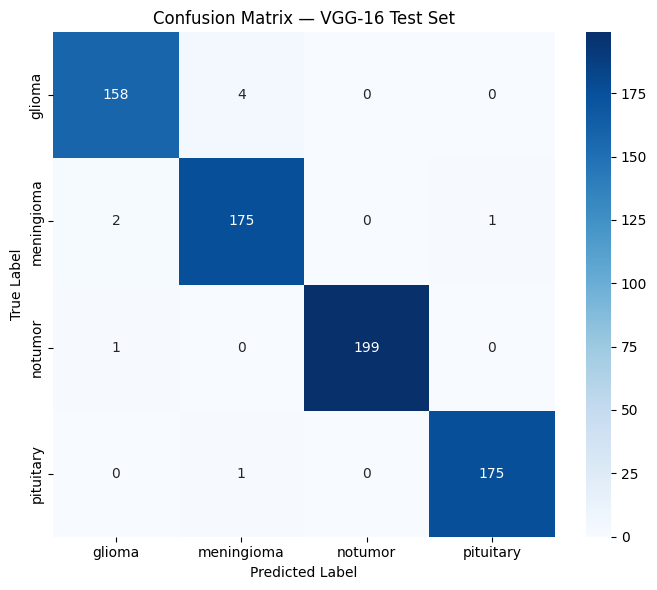

              precision    recall  f1-score   support

      glioma       0.98      0.98      0.98       162
  meningioma       0.97      0.98      0.98       178
     notumor       1.00      0.99      1.00       200
   pituitary       0.99      0.99      0.99       176

    accuracy                           0.99       716
   macro avg       0.99      0.99      0.99       716
weighted avg       0.99      0.99      0.99       716



In [16]:
all_preds, all_labels = [], []
model.eval()
with torch.no_grad():
    for imgs, labels in test_loader:
        preds = model(imgs.to(device)).argmax(1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("Confusion Matrix — VGG-16 Test Set")
plt.ylabel("True Label"); plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig("vgg16_confusion_matrix.png", dpi=150)
plt.show()

print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

## STEP 15 — Grad-CAM Visualisation

Grad-CAM computes a class-discriminative heatmap by weighting the activations of the last convolutional layer (`conv5_3`, `features[28]`) with the class-specific gradients via global average pooling. This produces a spatial saliency map directly comparable to ViT attention rollout for qualitative analysis in the paper.

> `inplace=False` on all model ReLUs (set in `__init__`) is what makes backward hooks work correctly here — no patching required.

In [17]:
# Force disable inplace ReLU on the loaded model
for module in model.modules():
    if isinstance(module, nn.ReLU):
        module.inplace = False

print("inplace ReLU disabled — Grad-CAM ready.")

inplace ReLU disabled — Grad-CAM ready.


Sample : /content/brain_tumor_dataset/brain-tumor-mri-dataset/meningioma/me-0637.jpg


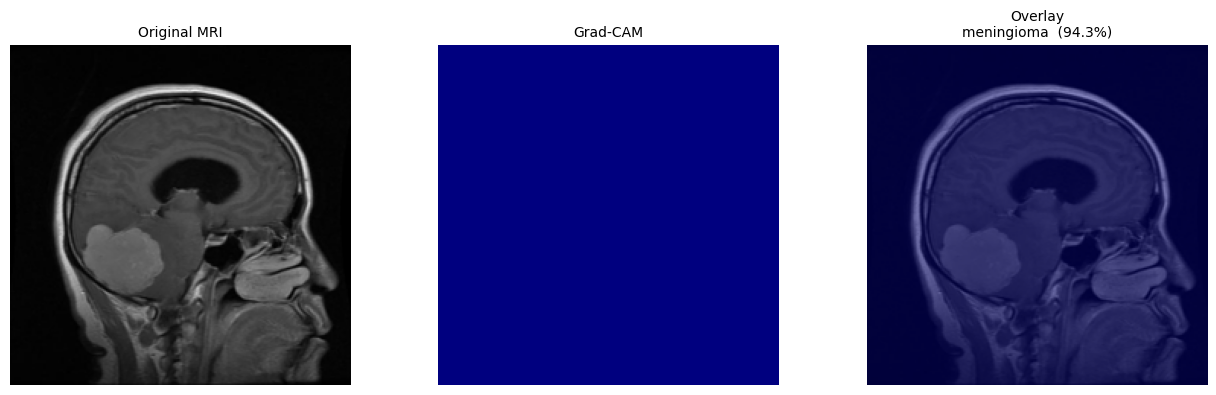

In [20]:
import cv2
from PIL import Image


def compute_grad_cam(model, tensor, target_class=None):
    """Compute normalised Grad-CAM heatmap (H×W float32) for a (1,3,H,W) tensor.
    Target layer: conv5_3 (model.features[28]).
    """
    model.eval()
    acts, grads = {}, {}
    layer = model.features[28]  # conv5_3 — last conv, most semantic

    h1 = layer.register_forward_hook(
        lambda m, i, o: acts.update({"f": o.detach()}))
    h2 = layer.register_full_backward_hook(
        lambda m, gi, go: grads.update({"g": go[0].detach()}))

    out = model(tensor.to(device))
    idx = target_class if target_class is not None else out.argmax(1).item()
    model.zero_grad()
    out[0, idx].backward()
    h1.remove(); h2.remove()

    weights = grads["g"].mean(dim=(2, 3), keepdim=True)         # (1, 512, 1, 1)
    cam     = (weights * acts["f"]).sum(1).squeeze()             # (7, 7)
    cam     = torch.relu(cam).cpu().numpy()
    cam     = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    return cam, idx


def visualize_grad_cam(image_path, alpha=0.45):
    """Overlay Grad-CAM on a single MRI image and save."""
    img_pil = Image.open(image_path).convert("RGB")
    img_np  = np.array(img_pil.resize((224, 224)))
    tensor  = val_test_transform(img_pil).unsqueeze(0)

    cam, pred_idx = compute_grad_cam(model, tensor)
    cam_up  = cv2.resize(cam, (224, 224))
    heatmap = cv2.cvtColor(
        cv2.applyColorMap(np.uint8(255 * cam_up), cv2.COLORMAP_JET),
        cv2.COLOR_BGR2RGB)
    overlay = np.clip(alpha*heatmap + (1-alpha)*img_np, 0, 255).astype(np.uint8)

    with torch.no_grad():
        probs = torch.softmax(model(tensor.to(device)), 1)[0]
    label = f"{CLASS_NAMES[pred_idx]}  ({probs[pred_idx]*100:.1f}%)"

    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    for ax, im, t in zip(axes,
                         [img_np, cam_up, overlay],
                         ["Original MRI", "Grad-CAM", f"Overlay\n{label}"]):
        ax.imshow(im, cmap="jet" if "CAM" in t else None)
        ax.set_title(t, fontsize=10); ax.axis("off")
    plt.tight_layout()
    plt.savefig("vgg16_gradcam.png", dpi=150, bbox_inches="tight")
    plt.show()


# Run on first available test image
sample_path = next(
    os.path.join(root, f)
    for root, _, files in os.walk(TEST_DIR)
    for f in files if f.lower().endswith((".jpg", ".jpeg", ".png"))
)
print(f"Sample : {sample_path}")
visualize_grad_cam(sample_path)

## STEP 16 — Grad-CAM Grid (one sample per class)

This figure is directly usable in the paper — shows the discriminative regions VGG-16 activates for each tumour class, alongside the true and predicted labels.

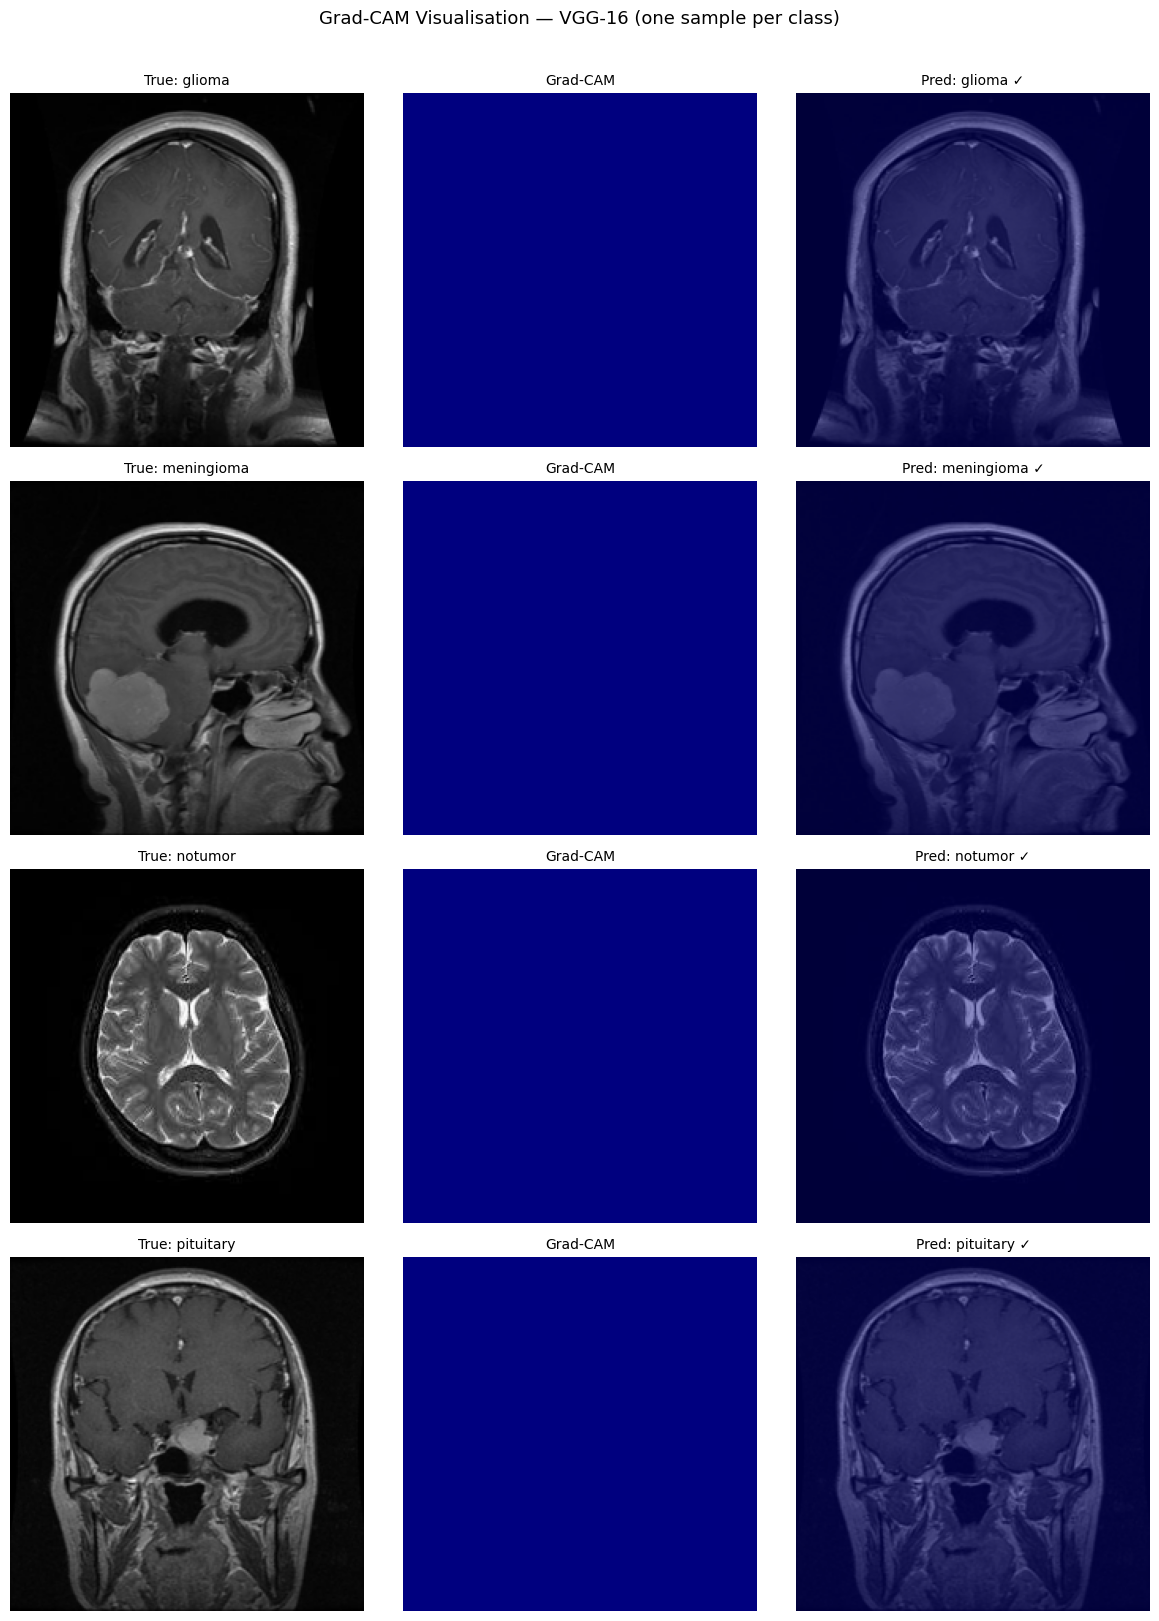

In [22]:
# Collect first available image per class from test set
class_samples = {}
for root, _, files in os.walk(TEST_DIR):
    cls = os.path.basename(root)
    if cls in CLASS_NAMES and cls not in class_samples:
        imgs_in = [f for f in files if f.lower().endswith((".jpg", ".jpeg", ".png"))]
        if imgs_in:
            class_samples[cls] = os.path.join(root, imgs_in[0])

fig, axes = plt.subplots(len(CLASS_NAMES), 3,
                         figsize=(12, 4 * len(CLASS_NAMES)))

for row, cls in enumerate(CLASS_NAMES):
    path    = class_samples.get(cls)
    if path is None: continue
    img_pil = Image.open(path).convert("RGB")
    img_np  = np.array(img_pil.resize((224, 224)))
    tensor  = val_test_transform(img_pil).unsqueeze(0)
    cam, pred_idx = compute_grad_cam(model, tensor)
    cam_up  = cv2.resize(cam, (224, 224))
    heatmap = cv2.cvtColor(
        cv2.applyColorMap(np.uint8(255 * cam_up), cv2.COLORMAP_JET),
        cv2.COLOR_BGR2RGB)
    overlay = np.clip(0.45*heatmap + 0.55*img_np, 0, 255).astype(np.uint8)

    correct = CLASS_NAMES[pred_idx] == cls
    pred_str = f"Pred: {CLASS_NAMES[pred_idx]}" + (" ✓" if correct else " ✗")

    axes[row,0].imshow(img_np)
    axes[row,0].set_title(f"True: {cls}", fontsize=10)
    axes[row,1].imshow(cam_up, cmap="jet")
    axes[row,1].set_title("Grad-CAM", fontsize=10)
    axes[row,2].imshow(overlay)
    axes[row,2].set_title(pred_str, fontsize=10)
    for ax in axes[row]: ax.axis("off")

plt.suptitle("Grad-CAM Visualisation — VGG-16 (one sample per class)",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("vgg16_gradcam_grid.png", dpi=150, bbox_inches="tight")
plt.show()